# Hoja de Trabajo 2 — DCGAN para sprites de Pokémon
Juan Diego Solís Martínez - 23720

Victor Manuel Pérez Chávez - 23714


## Task 1: Implementación completa
### Instalación y dependencias

In [1]:
!pip install torch torchvision matplotlib requests pillow --quiet

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.utils as vutils
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import requests
import os
from PIL import Image
from io import BytesIO
import time

# Reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

# Dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando dispositivo: {device}')

Usando dispositivo: cpu


### Parámetros fijos

In [3]:
# Task 1.1 - Parámetros fijos según la hoja de trabajo
Z_DIM = 100
IMG_SIZE = 64
IMG_CHANNELS = 3
FEATURES_G = 64
FEATURES_D = 64

# Task 1.2 - Parámetros de entrenamiento (DCGAN)
BATCH_SIZE = 32
NUM_EPOCHS = 50
LR = 2e-4
BETAS = (0.5, 0.999)

print('Hiperparámetros configurados correctamente.')

Hiperparámetros configurados correctamente.


### Dataset: Descarga de sprites desde el PokeAPI

In [4]:
def download_pokemon_sprites(save_dir='pokemon_sprites', max_pokemon=898):
    os.makedirs(save_dir, exist_ok=True)

    base_url = "https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon/"
    downloaded = 0
    failed = 0

    print(f'Descargando sprites de {max_pokemon} Pokémon:')

    for pokemon_id in range(1, max_pokemon + 1):
        filepath = os.path.join(save_dir, f'{pokemon_id}.png')

        if os.path.exists(filepath):
            downloaded += 1
            continue

        url = f"{base_url}{pokemon_id}.png"

        try:
            response = requests.get(url, timeout=10)
            if response.status_code == 200:
                img = Image.open(BytesIO(response.content)).convert('RGBA')

                background = Image.new('RGB', img.size, (255, 255, 255))
                background.paste(img, mask=img.split()[3])
                background.save(filepath)
                downloaded += 1

            else:
                failed += 1

        except Exception as e:
            failed += 1

        if pokemon_id % 100 == 0:
            print(f' - Progreso: {pokemon_id}/{max_pokemon} — descargados: {downloaded}, fallidos: {failed}')
        time.sleep(0.05)

    print(f'\nDescarga completada: {downloaded} sprites, {failed} fallidos.')
    return save_dir

sprite_dir = download_pokemon_sprites() # Descargar sprites

Descargando sprites de 898 Pokémon:
 - Progreso: 100/898 — descargados: 100, fallidos: 0
 - Progreso: 200/898 — descargados: 200, fallidos: 0
 - Progreso: 300/898 — descargados: 300, fallidos: 0
 - Progreso: 400/898 — descargados: 400, fallidos: 0
 - Progreso: 500/898 — descargados: 500, fallidos: 0
 - Progreso: 600/898 — descargados: 600, fallidos: 0
 - Progreso: 700/898 — descargados: 700, fallidos: 0
 - Progreso: 800/898 — descargados: 800, fallidos: 0

Descarga completada: 898 sprites, 0 fallidos.


In [5]:
class PokemonDataset(Dataset):
    # Dataset de sprites de Pokémon.
    # Aplica transformaciones: r000esize a 64x64, normalización a [-1, 1]
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform
        self.image_files = [
            f for f in os.listdir(image_dir)
            if f.endswith('.png') or f.endswith('.jpg')
        ]
        print(f'Dataset: {len(self.image_files)} imágenes encontradas.')

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_files[idx])
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img

# Transformaciones: resize + tensor + normalización [-1, 1]
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

dataset = PokemonDataset(sprite_dir, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)

print(f'DataLoader: {len(dataloader)} batches de tamaño {BATCH_SIZE}')

Dataset: 898 imágenes encontradas.
DataLoader: 28 batches de tamaño 32


## Task 1.1 | Arquitecturas del Generador y Discriminador

In [6]:
# Inicialización de pesos
# - Capas Conv/ConvTranspose: N(0, 0.02)
# - BatchNorm: gamma ~ N(1, 0.02), beta = 0
def initialize_weights(model):
    for m in model.modules():
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
            nn.init.normal_(m.weight.data, 0.0, 0.02)

        elif isinstance(m, nn.BatchNorm2d):
            nn.init.normal_(m.weight.data, 1.0, 0.02)
            nn.init.constant_(m.bias.data, 0)

In [7]:
# Generador DCGAN
# Entrada: z ∈ R^100 con forma (batch, 100, 1, 1)
# Salida: imagen con forma (batch, 3, 64, 64)
class Generator(nn.Module):
    def __init__(self, z_dim, img_channels, features_g):
        super(Generator, self).__init__()

        self.net = nn.Sequential(
            # Capa 1: z (B,100,1,1) → (B, FG*8, 4, 4)
            # Primera capa: sin padding, stride=1 para expandir desde 1x1
            self._block(z_dim, features_g * 8, kernel_size=4, stride=1, padding=0),

            # Capa 2: (B, FG*8, 4, 4) → (B, FG*4, 8, 8)
            self._block(features_g * 8, features_g * 4, kernel_size=4, stride=2, padding=1),

            # Capa 3: (B, FG*4, 8, 8) → (B, FG*2, 16, 16)
            self._block(features_g * 4, features_g * 2, kernel_size=4, stride=2, padding=1),

            # Capa 4: (B, FG*2, 16, 16) → (B, FG, 32, 32)
            self._block(features_g * 2, features_g, kernel_size=4, stride=2, padding=1),

            # Capa 5 (salida): (B, FG, 32, 32) → (B, 3, 64, 64)
            nn.ConvTranspose2d(features_g, img_channels, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )

    # Bloque: ConvTranspose2d -> BatchNorm2d -> ReLU
    def _block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size, stride, padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, z):
        return self.net(z)

In [8]:
# Discriminador DCGAN
# Entrada: imagen con forma (batch, 3, 64, 64)
# Salida:  escalar por imagen con forma (batch,)
class Discriminator(nn.Module):
    def __init__(self, img_channels, features_d):
        super(Discriminator, self).__init__()

        self.net = nn.Sequential(
            # Capa 1: (B, 3, 64, 64) -> (B, FD, 32, 32) | SIN BatchNorm
            nn.Conv2d(img_channels, features_d, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # Capa 2: (B, FD, 32, 32) -> (B, FD*2, 16, 16)
            self._block(features_d, features_d * 2, kernel_size=4, stride=2, padding=1),

            # Capa 3: (B, FD*2, 16, 16) -> (B, FD*4, 8, 8)
            self._block(features_d * 2, features_d * 4, kernel_size=4, stride=2, padding=1),

            # Capa 4: (B, FD*4, 8, 8) → (B, FD*8, 4, 4)
            self._block(features_d * 4, features_d * 8, kernel_size=4, stride=2, padding=1),

            # Capa 5 (salida): (B, FD*8, 4, 4) -> (B, 1, 1, 1)
            # Sin BatchNorm, Sigmoid para clasificación binaria
            nn.Conv2d(features_d * 8, 1, kernel_size=4, stride=1, padding=0, bias=False),
            nn.Sigmoid()
        )

    # Bloque Conv2d -> BatchNorm2d -> LeakyReLU(0.2)
    def _block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2, inplace=True)
        )

    def forward(self, x):
        return self.net(x).view(-1)

In [9]:
# Instanciar modelos
G = Generator(Z_DIM, IMG_CHANNELS, FEATURES_G).to(device)
D = Discriminator(IMG_CHANNELS, FEATURES_D).to(device)

# Aplicar inicialización de pesos
initialize_weights(G)
initialize_weights(D)

# Verificar formas
z_test = torch.randn(4, Z_DIM, 1, 1).to(device)

assert G(z_test).shape == (4, 3, 64, 64), "Forma del generador incorrecta"
assert D(torch.randn(4, 3, 64, 64).to(device)).shape == (4,), "Forma del discriminador incorrecta"

print('Verificación de formas OK')
print(f' - G(z).shape = {G(z_test).shape}   (esperado: (4, 3, 64, 64))')
print(f' - D(x).shape = {D(torch.randn(4,3,64,64).to(device)).shape}   (esperado: (4,))')

Verificación de formas OK
 - G(z).shape = torch.Size([4, 3, 64, 64])   (esperado: (4, 3, 64, 64))
 - D(x).shape = torch.Size([4])   (esperado: (4,))


## Task 1.2 | Entrenamiento alternado

In [10]:
# Función de pérdida: BCE
# V(D,G) = E[log D(x)] + E[log(1 - D(G(z)))]
criterion = nn.BCELoss()

# Optimizadores Adam con lr=2e-4 y betas=(0.5, 0.999)
# beta1=0.5 (en lugar de 0.9) da mayor estabilidad
opt_D = optim.Adam(D.parameters(), lr=LR, betas=BETAS)
opt_G = optim.Adam(G.parameters(), lr=LR, betas=BETAS)

# Vector de ruido FIJO para visualizar evolución del generador
fixed_noise = torch.randn(16, Z_DIM, 1, 1).to(device)

# Listas para registrar pérdidas por época
history_loss_G = []
history_loss_D = []

# Guardar grillas de imágenes por época
os.makedirs('generated_grids', exist_ok=True)

print('Configuración de entrenamiento lista.')
print(f'  Épocas:      {NUM_EPOCHS}')
print(f'  Batch size:  {BATCH_SIZE}')
print(f'  LR:          {LR}')
print(f'  Betas:       {BETAS}')
print(f'  Batches/época: {len(dataloader)}')

Configuración de entrenamiento lista.
  Épocas:      50
  Batch size:  32
  LR:          0.0002
  Betas:       (0.5, 0.999)
  Batches/época: 28


In [11]:
#  LOOP DE ENTRENAMIENTO DCGAN
G.train()
D.train()

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_loss_G = 0.0
    epoch_loss_D = 0.0
    num_batches  = 0

    for real_imgs in dataloader:
        real_imgs = real_imgs.to(device)
        batch_sz  = real_imgs.size(0)

        # -- PASO DEL DISCRIMINADOR --
        # Objetivo: maximizar E[log D(x)] + E[log(1 - D(G(z)))]
        # Equivalente: minimizar BCE(D(x), 1) + BCE(D(G(z)), 0)
        D.zero_grad()

        # Datos reales (etiqueta = 1)
        real_labels = torch.ones(batch_sz).to(device)
        pred_real = D(real_imgs)
        loss_D_real = criterion(pred_real, real_labels) # −E[log D(x)]

        # Datos falsos (etiqueta = 0)
        noise = torch.randn(batch_sz, Z_DIM, 1, 1).to(device)
        fake_imgs = G(noise)
        fake_labels = torch.zeros(batch_sz).to(device)

        # .detach() evita propagar gradientes hacia G durante el paso de D
        pred_fake = D(fake_imgs.detach())
        loss_D_fake = criterion(pred_fake, fake_labels) # −E[log(1−D(G(z)))]

        # Pérdida total del discriminador
        loss_D = loss_D_real + loss_D_fake
        loss_D.backward()
        opt_D.step()

        # -- PASO DEL GENERADOR --
        # Objetivo (truco de Goodfellow): maximizar E[log D(G(z))]
        # Equivalente: minimizar BCE(D(G(z)), 1)
        G.zero_grad()

        # Generar un nuevo batch
        noise_G    = torch.randn(batch_sz, Z_DIM, 1, 1).to(device)
        fake_imgs_G = G(noise_G)

        # El generador maximiza log D(G(z))
        pred_for_G  = D(fake_imgs_G)
        real_labels_G = torch.ones(batch_sz).to(device)
        loss_G      = criterion(pred_for_G, real_labels_G)
        loss_G.backward()
        opt_G.step()

        # Acumular pérdidas
        epoch_loss_D += loss_D.item()
        epoch_loss_G += loss_G.item()
        num_batches  += 1

    # Pérdidas promedio de la época
    avg_loss_D = epoch_loss_D / num_batches
    avg_loss_G = epoch_loss_G / num_batches

    history_loss_D.append(avg_loss_D)
    history_loss_G.append(avg_loss_G)

    # Guardar grilla
    G.eval()
    with torch.no_grad():
        fake_fixed = G(fixed_noise).cpu()
    G.train()

    grid = vutils.make_grid(fake_fixed, nrow=4, normalize=True)
    grid_np = grid.permute(1, 2, 0).numpy()
    plt.imsave(f'generated_grids/epoch_{epoch:03d}.png', grid_np)

    # Log de progreso
    print(f'Época [{epoch:3d}/{NUM_EPOCHS}]  '
          f'loss_D: {avg_loss_D:.4f}  '
          f'loss_G: {avg_loss_G:.4f}  '
          f'|diff|: {abs(avg_loss_D - avg_loss_G):.4f}')

print('\nEntrenamiento completado.')

Época [  1/50]  loss_D: 0.2971  loss_G: 8.1803  |diff|: 7.8833
Época [  2/50]  loss_D: 0.8237  loss_G: 16.8307  |diff|: 16.0070
Época [  3/50]  loss_D: 1.2414  loss_G: 14.5594  |diff|: 13.3180
Época [  4/50]  loss_D: 1.1683  loss_G: 9.6268  |diff|: 8.4585
Época [  5/50]  loss_D: 0.5463  loss_G: 7.3165  |diff|: 6.7702
Época [  6/50]  loss_D: 0.3198  loss_G: 6.9241  |diff|: 6.6043
Época [  7/50]  loss_D: 0.3754  loss_G: 6.8243  |diff|: 6.4489
Época [  8/50]  loss_D: 0.1773  loss_G: 4.7795  |diff|: 4.6022
Época [  9/50]  loss_D: 0.6091  loss_G: 5.5209  |diff|: 4.9118
Época [ 10/50]  loss_D: 0.7510  loss_G: 4.8566  |diff|: 4.1057
Época [ 11/50]  loss_D: 0.4629  loss_G: 5.3398  |diff|: 4.8770
Época [ 12/50]  loss_D: 0.3039  loss_G: 5.5697  |diff|: 5.2659
Época [ 13/50]  loss_D: 0.6986  loss_G: 5.7088  |diff|: 5.0103
Época [ 14/50]  loss_D: 0.3075  loss_G: 4.7402  |diff|: 4.4327
Época [ 15/50]  loss_D: 0.5333  loss_G: 5.4984  |diff|: 4.9652
Época [ 16/50]  loss_D: 0.5743  loss_G: 5.8623  |di

## Task 1.3 | Visualizaciones

### - Primera visualización: Grilla 4×4 de imágenes

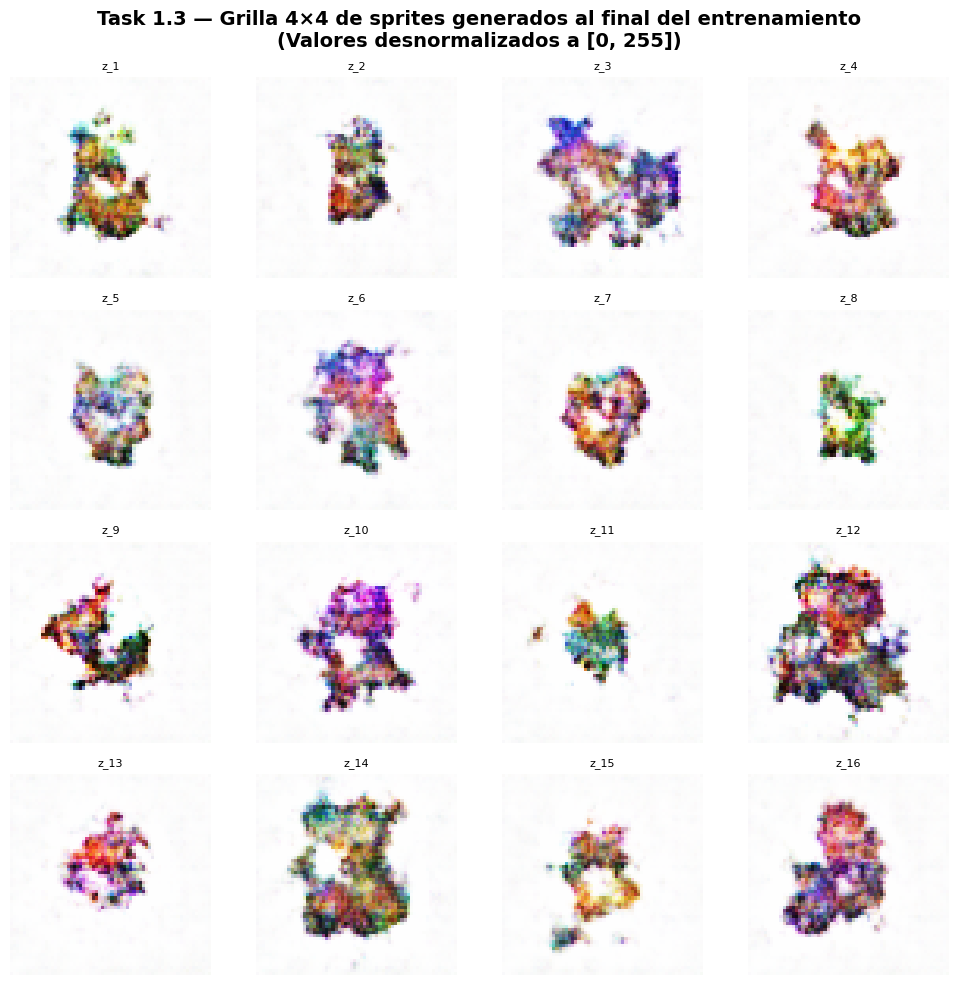

Grilla guardada en task1_3_grid_final.png


In [12]:
G.eval()
with torch.no_grad():
    final_imgs = G(fixed_noise).cpu()

# Desnormalizar: x_orig = (x_norm * 0.5 + 0.5) * 255
# La normalización fue: x_norm = (x - 0.5) / 0.5  -> x = x_norm * 0.5 + 0.5
final_imgs_denorm = (final_imgs * 0.5 + 0.5).clamp(0, 1) # [0, 1]
final_imgs_255 = (final_imgs_denorm * 255).byte() # [0, 255]

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle('Task 1.3 — Grilla 4×4 de sprites generados al final del entrenamiento\n'
             '(Valores desnormalizados a [0, 255])', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    img = final_imgs_255[i].permute(1, 2, 0).numpy()  # (H, W, C)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'z_{i+1}', fontsize=8)

plt.tight_layout()
plt.savefig('task1_3_grid_final.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grilla guardada en task1_3_grid_final.png')

### - Segunda visualización: Curvas de loss_G y loss_D con punto de convergencia

Punto de pérdidas más cercanas:
  Época: 38
  loss_G: 3.6507
  loss_D: 0.5076
  |diff|: 3.1431


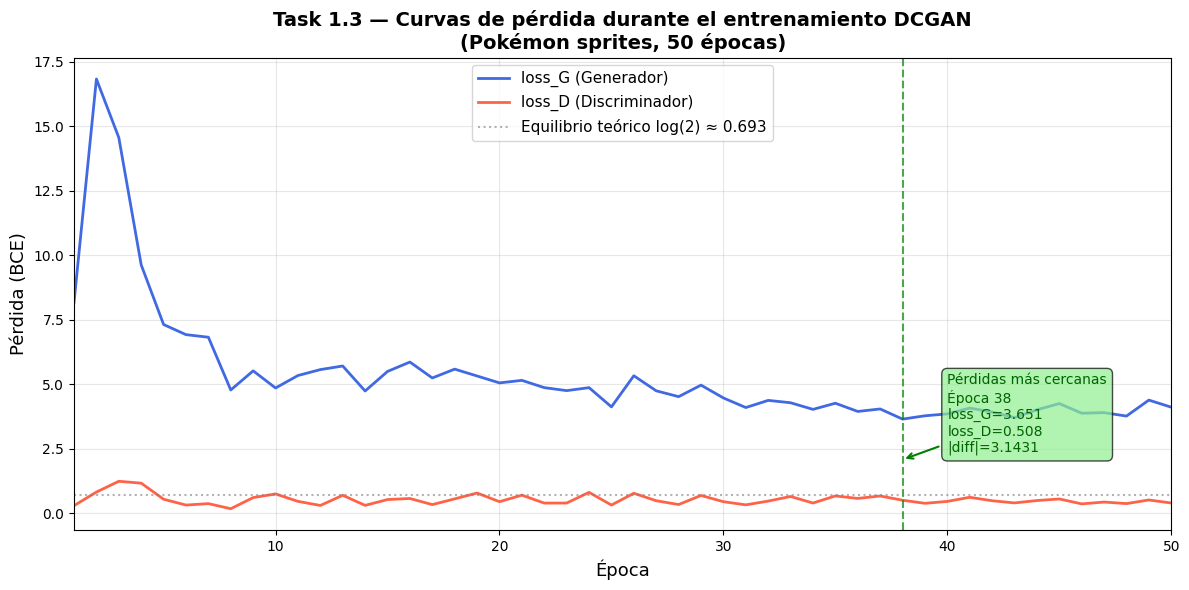

Curvas de pérdida guardadas en task1_3_loss_curves.png


In [13]:
epochs_axis = list(range(1, NUM_EPOCHS + 1))

# Encontrar la época donde las pérdidas son más cercanas entre sí
diff = [abs(history_loss_G[i] - history_loss_D[i]) for i in range(NUM_EPOCHS)]
closest_epoch = epochs_axis[np.argmin(diff)]
min_diff      = min(diff)

print(f'Punto de pérdidas más cercanas:')
print(f'  Época: {closest_epoch}')
print(f'  loss_G: {history_loss_G[closest_epoch-1]:.4f}')
print(f'  loss_D: {history_loss_D[closest_epoch-1]:.4f}')
print(f'  |diff|: {min_diff:.4f}')

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(epochs_axis, history_loss_G, label='loss_G (Generador)', color='royalblue', linewidth=2)
ax.plot(epochs_axis, history_loss_D, label='loss_D (Discriminador)', color='tomato', linewidth=2)

# Anotar el punto donde las pérdidas son más cercanas
close_y = (history_loss_G[closest_epoch-1] + history_loss_D[closest_epoch-1]) / 2
ax.axvline(x=closest_epoch, color='green', linestyle='--', alpha=0.7, linewidth=1.5)
ax.annotate(
    f'Pérdidas más cercanas\nÉpoca {closest_epoch}\n'
    f'loss_G={history_loss_G[closest_epoch-1]:.3f}\n'
    f'loss_D={history_loss_D[closest_epoch-1]:.3f}\n'
    f'|diff|={min_diff:.4f}',
    xy=(closest_epoch, close_y),
    xytext=(closest_epoch + 2, close_y + 0.3),
    arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
    fontsize=10,
    color='darkgreen',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='lightgreen', alpha=0.7)
)

# Línea teórica de equilibrio: en el equilibrio de Nash, loss_D ≈ log(2) ≈ 0.693
ax.axhline(y=np.log(2), color='gray', linestyle=':', alpha=0.6, linewidth=1.5, label=f'Equilibrio teórico log(2) ≈ {np.log(2):.3f}')

ax.set_xlabel('Época', fontsize=13)
ax.set_ylabel('Pérdida (BCE)', fontsize=13)
ax.set_title('Task 1.3 — Curvas de pérdida durante el entrenamiento DCGAN\n'
             '(Pokémon sprites, 50 épocas)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(1, NUM_EPOCHS)

plt.tight_layout()
plt.savefig('task1_3_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Curvas de pérdida guardadas en task1_3_loss_curves.png')

In [14]:
# Resumen
print('RESUMEN de Task 1')
print('\nTask 1.1: Arquitecturas DCGAN implementadas y verificadas')
print(f' - Generador: z(B,100,1,1) -> imagen(B,3,64,64)')
print(f' - Discriminador: imagen(B,3,64,64) -> escalar(B,)')

print('\nTask 1.2: Entrenamiento alternado completado')
print(f' - Épocas entrenadas: {NUM_EPOCHS}')
print(f' - loss_G final: {history_loss_G[-1]:.4f}')
print(f' - loss_D final: {history_loss_D[-1]:.4f}')
print(f' - Grillas guardadas en: generated_grids/')

print('\nTask 1.3: Visualizaciones generadas')
print(f' - Grilla 4x4 final:   task1_3_grid_final.png')
print(f' - Curvas de pérdida:  task1_3_loss_curves.png')
print(f' - Pérdidas más cercanas en época {closest_epoch} (|diff|={min_diff:.4f})')

RESUMEN de Task 1

Task 1.1: Arquitecturas DCGAN implementadas y verificadas
 - Generador: z(B,100,1,1) -> imagen(B,3,64,64)
 - Discriminador: imagen(B,3,64,64) -> escalar(B,)

Task 1.2: Entrenamiento alternado completado
 - Épocas entrenadas: 50
 - loss_G final: 4.1125
 - loss_D final: 0.3991
 - Grillas guardadas en: generated_grids/

Task 1.3: Visualizaciones generadas
 - Grilla 4x4 final:   task1_3_grid_final.png
 - Curvas de pérdida:  task1_3_loss_curves.png
 - Pérdidas más cercanas en época 38 (|diff|=3.1431)


## Guardar el modelo

In [15]:
# Guardar pesos
torch.save({
    'G_state_dict': G.state_dict(),
    'D_state_dict': D.state_dict(),
    'opt_G_state':  opt_G.state_dict(),
    'opt_D_state':  opt_D.state_dict(),
    'history_loss_G': history_loss_G,
    'history_loss_D': history_loss_D,
    'fixed_noise':  fixed_noise.cpu(),
}, 'dcgan_task1_checkpoint.pth')

print('Guardado: dcgan_task1_checkpoint.pth')

Guardado: dcgan_task1_checkpoint.pth
